# 04 — Step Purity Contract

**Invariants proved:** Cross-cutting validation of RNG partitioning, engine, and branched counterfactuals  
**Module built:** `tests/integration/test_step_purity.py`

This notebook demonstrates **the single most important test in the SDK**:

> Run the same scenario with `BRANCHED` and `NONE` modes, same seed. The factual branch from BRANCHED must be element-wise identical to the NONE trajectory.

If this test passes, it simultaneously proves:
- RNG partitioning works (streams are independent)
- Stream forking works (branches get the same seed state)
- Step purity holds (no shared mutable state leaks between branches)
- Engine RNG context swapping works correctly
- `clone_state` produces true independent copies

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

from sdk.core.engine import BranchedSimulationEngine, CounterfactualMode
from sdk.core.scenario import BaseScenario, TimeConfig, Predictions, Interventions, Outcomes

## A Stochastic Pure Scenario

This scenario has real randomness in `step()` (temporal noise) and `measure()` (stochastic outcomes), plus an intervention that modifies state. It uses the correct RNG streams throughout.

In [2]:
class StochasticPureScenario(BaseScenario[np.ndarray]):
    """Scenario with random draws in step/measure, using correct RNG streams."""
    unit_of_analysis = "entity"

    def create_population(self, n_entities):
        return self.rng.population.random(n_entities)

    def step(self, state, t):
        noise = self.rng.temporal.normal(0, 0.01, size=len(state))
        return np.clip(state + noise, 0, 1)

    def predict(self, state, t):
        noise = self.rng.prediction.normal(0, 0.1, size=len(state))
        return Predictions(scores=state + noise)

    def intervene(self, state, predictions, t):
        treated = predictions.scores > 0.5
        state = state.copy()
        state[treated] *= 0.5
        return state, Interventions(treated_indices=np.where(treated)[0])

    def measure(self, state, t):
        events = (self.rng.outcomes.random(len(state)) < state).astype(float)
        return Outcomes(events=events, entity_ids=np.arange(len(state)))

## 1. The Purity Test: BRANCHED Factual == NONE

Run the same scenario with both modes, same seed. Compare element-wise.

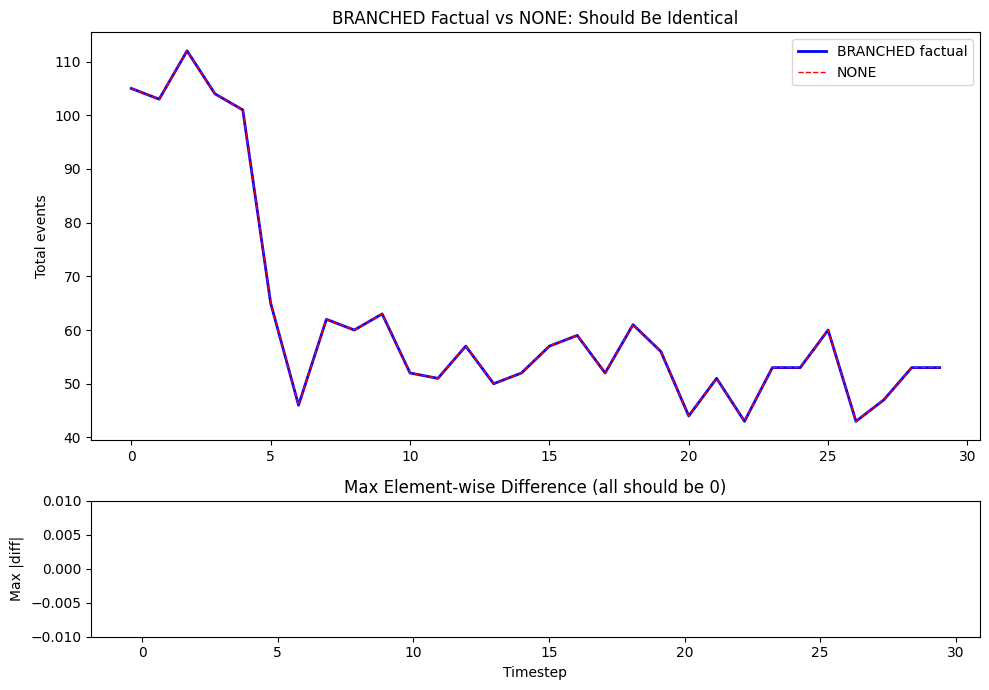

Total max difference across all timesteps: 0.0
PURITY TEST PASSED: BRANCHED factual is identical to NONE.


In [3]:
n_entities, n_timesteps, seed = 200, 30, 42
prediction_schedule = [5, 10, 15, 20, 25]
tc = TimeConfig(n_timesteps=n_timesteps, timestep_duration=1/52, prediction_schedule=prediction_schedule)

# Run BRANCHED
sc_b = StochasticPureScenario(time_config=tc, seed=seed)
results_b = BranchedSimulationEngine(sc_b, CounterfactualMode.BRANCHED).run(n_entities)

# Run NONE
sc_n = StochasticPureScenario(time_config=tc, seed=seed)
results_n = BranchedSimulationEngine(sc_n, CounterfactualMode.NONE).run(n_entities)

# Compare at every timestep
max_diffs = []
for t in range(n_timesteps):
    diff = np.abs(results_b.outcomes[t].events - results_n.outcomes[t].events).max()
    max_diffs.append(diff)

fig, axes = plt.subplots(2, 1, figsize=(10, 7), gridspec_kw={'height_ratios': [3, 1]})

# Trajectory overlay
branched_series = [results_b.outcomes[t].events.sum() for t in range(n_timesteps)]
none_series = [results_n.outcomes[t].events.sum() for t in range(n_timesteps)]
axes[0].plot(branched_series, 'b-', linewidth=2, label='BRANCHED factual')
axes[0].plot(none_series, 'r--', linewidth=1, label='NONE')
axes[0].set_ylabel('Total events')
axes[0].set_title('BRANCHED Factual vs NONE: Should Be Identical')
axes[0].legend()

# Difference
axes[1].bar(range(n_timesteps), max_diffs, color='green', alpha=0.7)
axes[1].set_xlabel('Timestep')
axes[1].set_ylabel('Max |diff|')
axes[1].set_title(f'Max Element-wise Difference (all should be 0)')
axes[1].set_ylim(-0.01, 0.01)

plt.tight_layout()
plt.show()

total_diff = sum(max_diffs)
print(f"Total max difference across all timesteps: {total_diff}")
assert total_diff == 0.0, f"PURITY VIOLATION: total diff = {total_diff}"
print("PURITY TEST PASSED: BRANCHED factual is identical to NONE.")

## 2. What Happens When Purity Is Violated

An **impure** scenario writes to `self.counter` in step() — shared mutable state that leaks between branches. In BRANCHED mode, step() is called twice per timestep (once per branch), so the counter advances 2x as fast as in NONE mode.

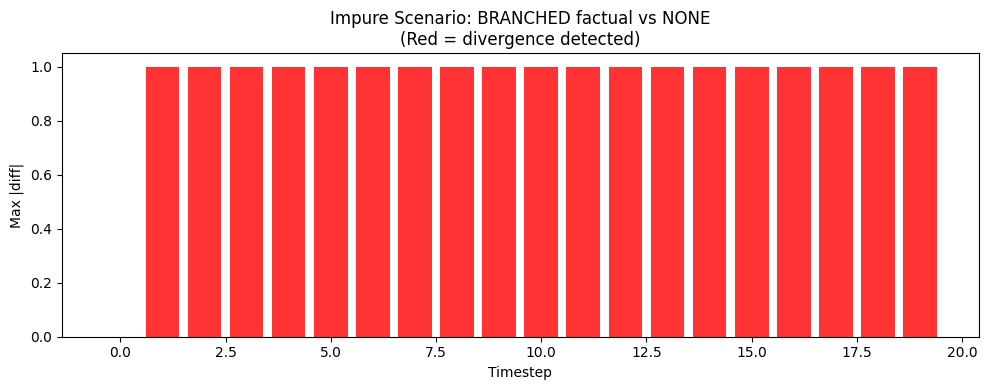

First divergence at t=1
This is a PURITY VIOLATION — shared mutable state leaks between branches.


In [4]:
class ImpureScenario(BaseScenario[np.ndarray]):
    """DELIBERATELY BROKEN: step writes to shared self.counter."""
    unit_of_analysis = "entity"
    def __init__(self, *a, **kw):
        super().__init__(*a, **kw)
        self.counter = 0  # shared mutable state!

    def create_population(self, n): return self.rng.population.random(n)
    def step(self, state, t):
        self.counter += 1  # BUG: in BRANCHED mode, called 2x per timestep
        noise = self.rng.temporal.normal(0, 0.01, size=len(state))
        return np.clip(state + noise * self.counter, 0, 1)
    def predict(self, state, t): return Predictions(scores=state.copy())
    def intervene(self, state, pred, t):
        treated = pred.scores > 0.5
        state = state.copy(); state[treated] *= 0.5
        return state, Interventions(treated_indices=np.where(treated)[0])
    def measure(self, state, t):
        events = (self.rng.outcomes.random(len(state)) < state).astype(float)
        return Outcomes(events=events, entity_ids=np.arange(len(state)))

tc = TimeConfig(n_timesteps=20, timestep_duration=1/52, prediction_schedule=[5, 10, 15])

# Run BRANCHED and NONE
sc_b = ImpureScenario(time_config=tc, seed=42)
res_b = BranchedSimulationEngine(sc_b, CounterfactualMode.BRANCHED).run(200)

sc_n = ImpureScenario(time_config=tc, seed=42)
res_n = BranchedSimulationEngine(sc_n, CounterfactualMode.NONE).run(200)

diffs = [np.abs(res_b.outcomes[t].events - res_n.outcomes[t].events).max() for t in range(20)]

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['red' if d > 0 else 'green' for d in diffs]
ax.bar(range(20), diffs, color=colors, alpha=0.8)
ax.set_xlabel('Timestep')
ax.set_ylabel('Max |diff|')
ax.set_title('Impure Scenario: BRANCHED factual vs NONE\n(Red = divergence detected)')
plt.tight_layout()
plt.show()

first_violation = next(t for t, d in enumerate(diffs) if d > 0)
print(f"First divergence at t={first_violation}")
print(f"This is a PURITY VIOLATION — shared mutable state leaks between branches.")

## 3. What Happens with RNG Discipline Violation

Using the wrong RNG stream in `step()` causes the factual and counterfactual branches to diverge even when they shouldn't — because `intervene()` consumes the intervention stream on the factual branch, desynchronizing it from the counterfactual's intervention stream used by step().

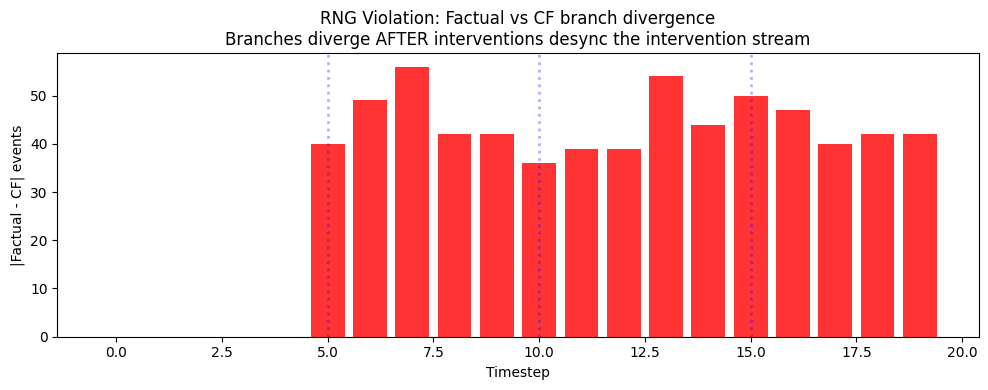

Pre-intervention divergence (t=0-4): 0.0
Post-intervention divergence (t=6-9): 189.0

Using the wrong stream causes spurious branch divergence after intervention.


In [5]:
class RNGViolationScenario(BaseScenario[np.ndarray]):
    """DELIBERATELY BROKEN: step uses intervention stream instead of temporal."""
    unit_of_analysis = "entity"
    def create_population(self, n): return self.rng.population.random(n)
    def step(self, state, t):
        noise = self.rng.intervention.normal(0, 0.01, size=len(state))  # WRONG STREAM
        return np.clip(state + noise, 0, 1)
    def predict(self, state, t): return Predictions(scores=state.copy())
    def intervene(self, state, pred, t):
        treated = pred.scores > 0.5
        state = state.copy(); state[treated] *= 0.5
        return state, Interventions(treated_indices=np.where(treated)[0])
    def measure(self, state, t):
        events = (self.rng.outcomes.random(len(state)) < state).astype(float)
        return Outcomes(events=events, entity_ids=np.arange(len(state)))

tc = TimeConfig(n_timesteps=20, timestep_duration=1/52, prediction_schedule=[5, 10, 15])
sc = RNGViolationScenario(time_config=tc, seed=42)
results = BranchedSimulationEngine(sc, CounterfactualMode.BRANCHED).run(200)

# Compare factual vs counterfactual outcomes
fc_diffs = []
for t in range(20):
    f_events = results.outcomes[t].events.sum()
    c_events = results.counterfactual_outcomes[t].events.sum()
    fc_diffs.append(abs(f_events - c_events))

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['red' if d > 1 else 'orange' if d > 0 else 'green' for d in fc_diffs]
ax.bar(range(20), fc_diffs, color=colors, alpha=0.8)
for pt in [5, 10, 15]:
    ax.axvline(x=pt, color='blue', alpha=0.3, linestyle=':', linewidth=2)
ax.set_xlabel('Timestep')
ax.set_ylabel('|Factual - CF| events')
ax.set_title('RNG Violation: Factual vs CF branch divergence\n'
             'Branches diverge AFTER interventions desync the intervention stream')
plt.tight_layout()
plt.show()

# Before first intervention, branches should be identical
pre_diff = sum(fc_diffs[:5])
post_diff = sum(fc_diffs[6:10])
print(f"Pre-intervention divergence (t=0-4): {pre_diff:.1f}")
print(f"Post-intervention divergence (t=6-9): {post_diff:.1f}")
print(f"\nUsing the wrong stream causes spurious branch divergence after intervention.")

## Key Insights

1. **The BRANCHED-vs-NONE identity test** is the gold standard for scenario correctness. Every new scenario should pass it.
2. **Impurity** (shared mutable state in step) causes immediate divergence — step() is called twice per timestep in BRANCHED mode.
3. **RNG stream misuse** causes divergence between factual and counterfactual branches after the first intervention, because `intervene()` consumes the misused stream only on the factual branch.
4. Both failure modes produce **silent** bugs — wrong counterfactual comparisons with no errors or exceptions. The purity test is the only way to catch them.

### The Checklist for New Scenarios:
- `step()` uses only `self.rng.temporal` and the passed-in `state`
- `step()` does not read or write `self.*` attributes (except `self.rng`)
- `predict()` uses only `self.rng.prediction`
- `intervene()` uses only `self.rng.intervention`
- `measure()` uses only `self.rng.outcomes`
- Run `assert_purity(MyScenario)` from `tests/integration/test_step_purity.py`

**Next:** NB05 — ML Binary Classifier (Phase 1 continues)